In [14]:
# Import required libraries
from pathlib import Path
from math import ceil

import kornia.augmentation as K

from tree_detection_framework.preprocessing.preprocessing import (
    create_dataloader,
    create_intersection_dataloader,
)
from tree_detection_framework.detection.detector import (
    GeometricTreeTopDetector,
    GeometricTreeCrownDetector,
)
from tree_detection_framework.constants import DATA_FOLDER
from tree_detection_framework.postprocessing.postprocessing import (
    remove_edge_detections,
    multi_region_NMS,
    single_region_hole_suppression,
)
from tree_detection_framework.preprocessing.preprocessing import visualize_dataloader
from tree_detection_framework.preprocessing.utils import KorniaTransformWrapper

In [15]:
# The path to a Canopy Height Model raster file
RASTER_FOLDER_PATH = Path(DATA_FOLDER, "emerald-point-chm")
RASTER_FILE_PATH = Path(RASTER_FOLDER_PATH, "chm.tif")
# Prediction file path
OUTPUT_TREETOPS_FILE_PATH = Path(
    RASTER_FOLDER_PATH, "emerald-point-chm-geometric-tree-tops.gpkg"
)
OUTPUT_TREECROWNS_FILE_PATH = Path(
    RASTER_FOLDER_PATH, "emerald-point-chm-geometric-tree-crowns.gpkg"
)
# The size of the chips in pixels
CHIP_SIZE = 512
# The stride between chips in pixels
CHIP_STRIDE = 400
# The spatial resolution that the data is sampled to in meters/pix
RESOLUTION = 0.2
# The blur resolution
BLUR_SIGMA_METERS = 0.5
# The number of tiles to show from the dataloader
N_VIS_TILES = 3

In [16]:
# Compute the kernel sigma in pixels
kernel_sigma_pixels = BLUR_SIGMA_METERS / RESOLUTION
# Set the kernel size to be odd and over two sigmas, which captures the vast majority of the probability density
kernel_size = 2 * ceil(kernel_sigma_pixels) + 1

# Create the transforms, including a wrapper that keeps singleton batches the same shape
transforms = KorniaTransformWrapper(
    K.AugmentationSequential(
        # Note that sigma is specified as an upper and lower bound. In this case, they are set identically
        K.RandomGaussianBlur(kernel_size=kernel_size, sigma=(kernel_sigma_pixels, kernel_sigma_pixels), p=1.0),
    )
)

# Stage 1: Create a dataloader for the raster data and detect the tree-tops
dataloader = create_dataloader(
    raster_folder_path=RASTER_FOLDER_PATH,
    chip_size=CHIP_SIZE,
    chip_stride=CHIP_STRIDE,
    resolution=RESOLUTION,
    raster_transforms=transforms,
)

INFO:root:Units = Units.PIXELS
INFO:root:Stride = 400


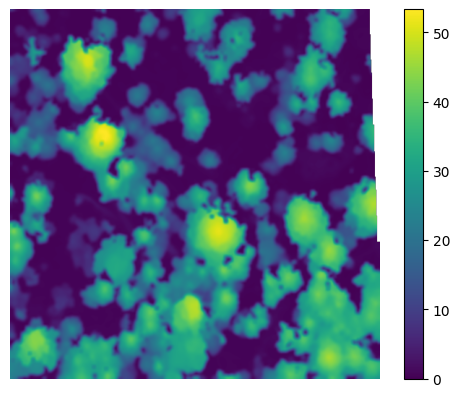

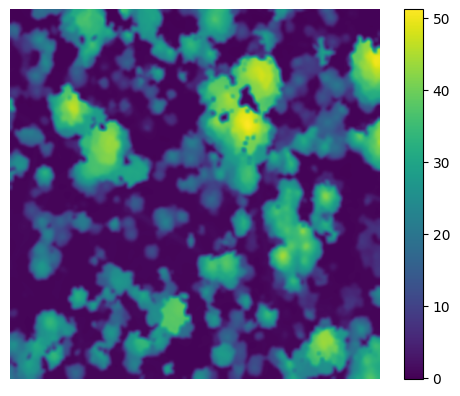

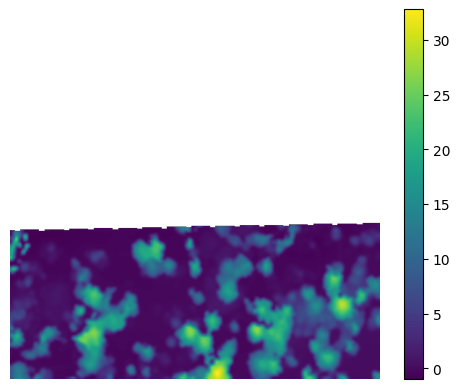

In [17]:
visualize_dataloader(dataloader, n_tiles=N_VIS_TILES)

In [18]:
treetop_detector = GeometricTreeTopDetector(
    a=0, b=0.0325, c=0.25, confidence_feature="height"
)

treetop_detections = treetop_detector.predict(dataloader)

Performing prediction on batches: 100%|██████████| 16/16 [00:07<00:00,  2.13it/s]


In [19]:
# Remove the tree tops that were generated in the edges of tiles. This is an alternative to NMS.
treetop_detections = remove_edge_detections(
    treetop_detections,
    suppression_distance=(CHIP_SIZE - CHIP_STRIDE) * RESOLUTION / 2,
)

In [20]:
# Optionally, save the treetops to disk
treetop_detections.save(OUTPUT_TREETOPS_FILE_PATH)

INFO:pyogrio._io:Created 1,377 records


In [21]:
# Stage 2: Combine raster and vector data (from the tree-top detector) to create a new dataloader
raster_vector_dataloader = create_intersection_dataloader(
    raster_data=RASTER_FOLDER_PATH,
    vector_data=treetop_detections,
    chip_size=CHIP_SIZE,
    chip_stride=CHIP_STRIDE,
    resolution=RESOLUTION,
)

treecrown_detector = GeometricTreeCrownDetector(approach="watershed")

treecrown_detections = treecrown_detector.predict(raster_vector_dataloader)

INFO:root:Stride = 400
INFO:root:Units = Units.PIXELS
INFO:pyogrio._io:Created 1,377 records
INFO:root:RegionDetectionsSet temporarily saved to: /tmp/tmpaczwpybx.geojson


Converting CustomRasterDataset CRS from EPSG:26910 to EPSG:26910


INFO:root:Using watershed approach to compute the tree crowns.
Performing prediction on batches: 100%|██████████| 12/12 [00:02<00:00,  4.37it/s]


In [22]:
# Suppress overlapping crown predictions. This step can be slow.
treecrown_detections = multi_region_NMS(
    treecrown_detections, confidence_column="score", intersection_method="IOS"
)

INFO:root:Bound have overlap, running across-region NMS


In [23]:
# Display outputs from the tree crown detector. Note: treetop UIDs get maintained.
treecrown_detections.get_data_frame()

,score,height,treetop_unique_ID,geometry,region_ID,unique_ID
6,767.0,36.251617,00467,"POLYGON ((752273.49 4317073.299, 752271.89 431...",0,00006
7,654.5,28.421659,00469,"POLYGON ((752238.09 4317072.299, 752236.89 431...",0,00007
10,1514.5,27.043137,00599,"POLYGON ((752328.49 4317071.499, 752327.09 431...",0,00010
11,89.0,23.368416,00475,"POLYGON ((752291.09 4317063.499, 752290.29 431...",0,00011
12,82.0,21.482374,00608,"POLYGON ((752326.09 4317062.899, 752324.89 431...",0,00012
...,...,...,...,...,...,...
2014,542.0,19.103931,01359,"POLYGON ((752467.49 4317220.899, 752466.29 431...",11,02014
2015,474.0,20.345129,01363,"POLYGON ((752435.89 4317219.099, 752434.29 431...",11,02015
2018,1520.0,34.634266,01362,"POLYGON ((752438.69 4317221.499, 752438.09 431...",11,02018
2019,512.5,12.712982,01367,"POLYGON ((752449.89 4317217.499, 752448.29 431...",11,02019


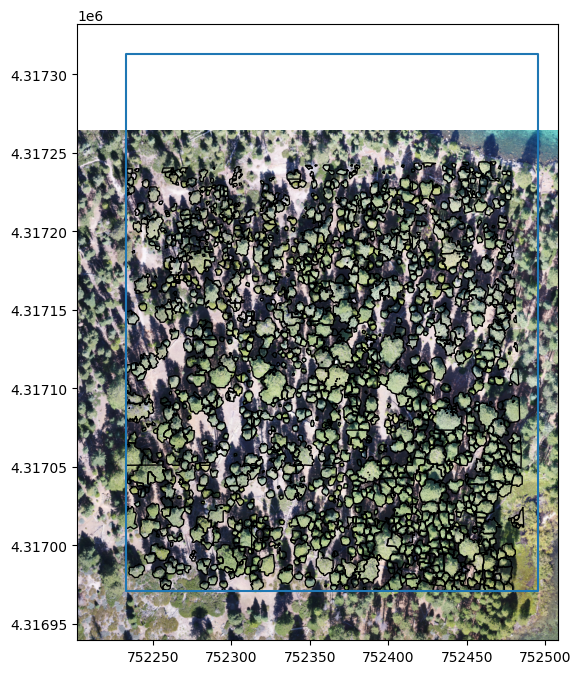

<Axes: >

In [24]:
treecrown_detections.plot(
    raster_file=Path(DATA_FOLDER, "emerald-point-ortho/ortho.tif")
)

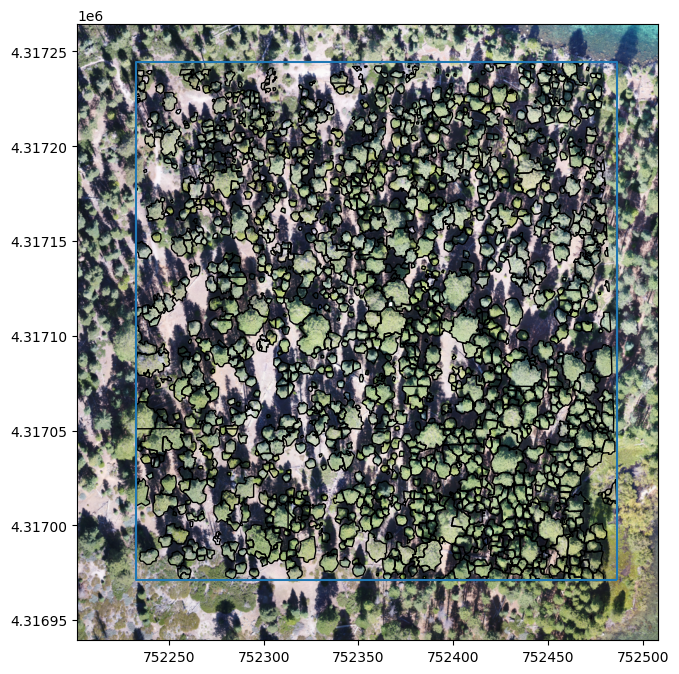

<Axes: >

In [25]:
# Post-processing step to remove holes in the tree crowns
treecrown_detections = single_region_hole_suppression(treecrown_detections)
treecrown_detections.plot(
    raster_file=Path(DATA_FOLDER, "emerald-point-ortho/ortho.tif")
)

In [26]:
treecrown_detections.save(OUTPUT_TREECROWNS_FILE_PATH)

INFO:pyogrio._io:Created 1,363 records
